In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [10]:
df = pd.read_csv('/kaggle/input/datasets/organizations/starbucks/store-locations/directory.csv')

In [11]:
df.head()

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,47370-257954,"Meritxell, 96",Licensed,"Av. Meritxell, 96",Andorra la Vella,7,AD,AD500,376818720,GMT+1:00 Europe/Andorra,1.53,42.51
1,Starbucks,22331-212325,Ajman Drive Thru,Licensed,"1 Street 69, Al Jarf",Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.42
2,Starbucks,47089-256771,Dana Mall,Licensed,Sheikh Khalifa Bin Zayed St.,Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.39
3,Starbucks,22126-218024,Twofour 54,Licensed,Al Salam Street,Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.38,24.48
4,Starbucks,17127-178586,Al Ain Tower,Licensed,"Khaldiya Area, Abu Dhabi Island",Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.54,24.51


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25600 non-null  object 
 1   Store Number    25600 non-null  object 
 2   Store Name      25600 non-null  object 
 3   Ownership Type  25600 non-null  object 
 4   Street Address  25598 non-null  object 
 5   City            25585 non-null  object 
 6   State/Province  25600 non-null  object 
 7   Country         25600 non-null  object 
 8   Postcode        24078 non-null  object 
 9   Phone Number    18739 non-null  object 
 10  Timezone        25600 non-null  object 
 11  Longitude       25599 non-null  float64
 12  Latitude        25599 non-null  float64
dtypes: float64(2), object(11)
memory usage: 2.5+ MB


In [13]:
df.isnull().sum()

Brand                0
Store Number         0
Store Name           0
Ownership Type       0
Street Address       2
City                15
State/Province       0
Country              0
Postcode          1522
Phone Number      6861
Timezone             0
Longitude            1
Latitude             1
dtype: int64

In [23]:
df.drop_duplicates(inplace=True)

In [22]:
df.fillna("Unknown", inplace=True)

In [21]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25600
Columns: 13


In [27]:
print("Question 1 - Which country has the highest number of Starbucks stores?")

Question 1 - Which country has the highest number of Starbucks stores?


In [24]:
country_count = df['Country'].value_counts()

print(country_count.head(10))

Country
US    13608
CN     2734
CA     1468
JP     1237
KR      993
GB      901
MX      579
TW      394
TR      326
PH      298
Name: count, dtype: int64


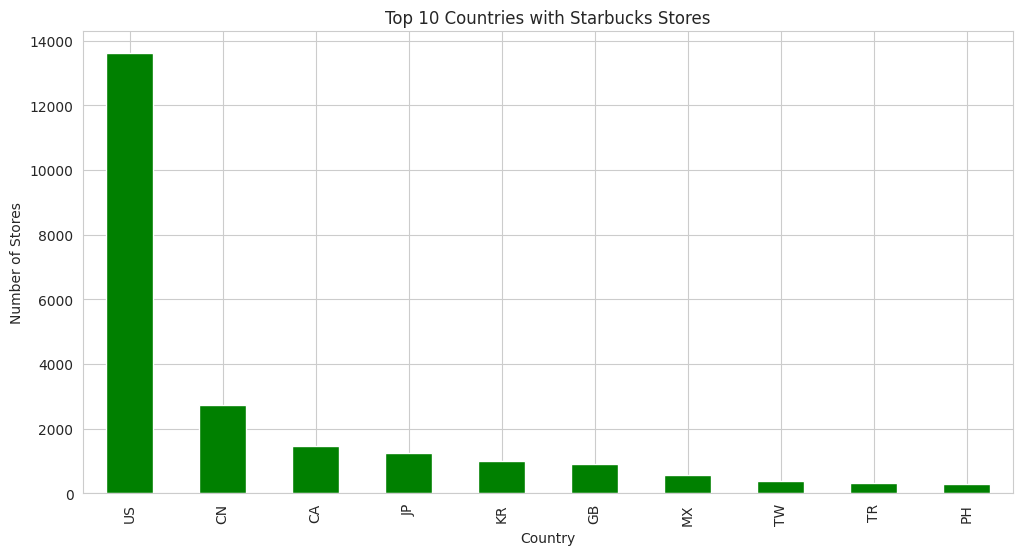

In [28]:
plt.figure(figsize=(12,6))
country_count.head(10).plot(kind='bar', color='green')
plt.title("Top 10 Countries with Starbucks Stores")
plt.xlabel("Country")
plt.ylabel("Number of Stores")
plt.show()

In [29]:
print("Question 2 - Which city has the highest number of stores?")

Question 2 - Which city has the highest number of stores?


In [30]:
city_count = df['City'].value_counts()

print(city_count.head(10))

City
上海市            542
Seoul          243
北京市            234
New York       232
London         216
Toronto        192
Mexico City    180
Chicago        180
Las Vegas      156
Seattle        156
Name: count, dtype: int64


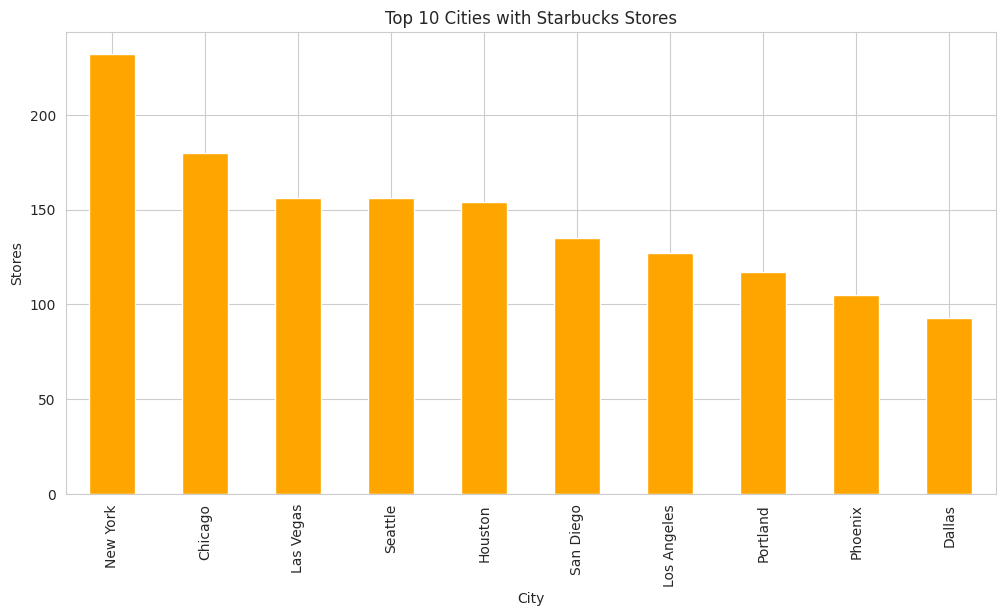

In [50]:
plt.figure(figsize=(12,6))
city_count.head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Cities with Starbucks Stores")
plt.xlabel("City")
plt.ylabel("Stores")
plt.show()

In [33]:
print("Question 3 - Which ownership type is most common?")

Question 3 - Which ownership type is most common?


In [34]:
ownership = df['Ownership Type'].value_counts()

print(ownership)

Ownership Type
Company Owned    11932
Licensed          9375
Joint Venture     3976
Franchise          317
Name: count, dtype: int64


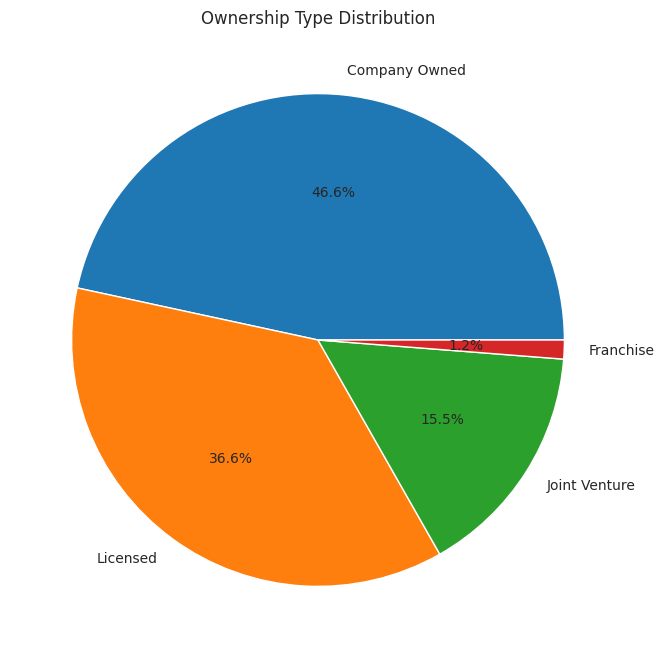

In [35]:
plt.figure(figsize=(8,8))
ownership.plot(kind='pie', autopct='%1.1f%%')
plt.title("Ownership Type Distribution")
plt.ylabel("")
plt.show()

In [36]:
print("Question 4 - Which timezone has the highest number of stores?")

Question 4 - Which timezone has the highest number of stores?


In [37]:
timezone = df['Timezone'].value_counts()

print(timezone.head(10))

Timezone
GMT-05:00 America/New_York       4889
GMT-08:00 America/Los_Angeles    4194
GMT-06:00 America/Chicago        2901
GMT+08:00 Asia/Beijing           2731
GMT+09:00 Asia/Tokyo             1237
GMT+09:00 Asia/Seoul              993
GMT+0:00 Europe/London            901
GMT-07:00 America/Denver          804
GMT-06:00 America/Mexico_City     531
GMT-05:00 America/Toronto         518
Name: count, dtype: int64


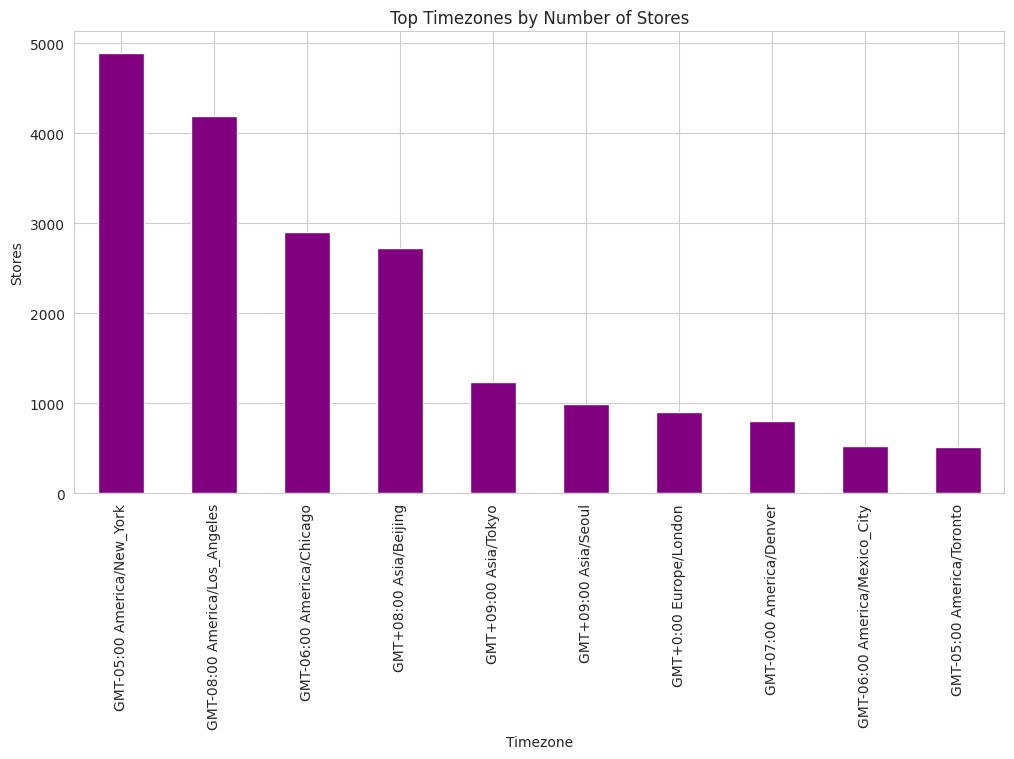

In [38]:
plt.figure(figsize=(12,6))
timezone.head(10).plot(kind='bar', color='purple')
plt.title("Top Timezones by Number of Stores")
plt.xlabel("Timezone")
plt.ylabel("Stores")
plt.show()

In [39]:
print("Question 5 - Which country has the highest number of company-owned stores?")

Question 5 - Which country has the highest number of company-owned stores?


In [40]:
company = df[df['Ownership Type']=="Company Owned"]

company_country = company['Country'].value_counts()

print(company_country.head(10))

Country
US    8226
CN    1339
CA    1097
GB     347
TH     289
DE     142
SG     130
BR     102
JP     101
FR      74
Name: count, dtype: int64


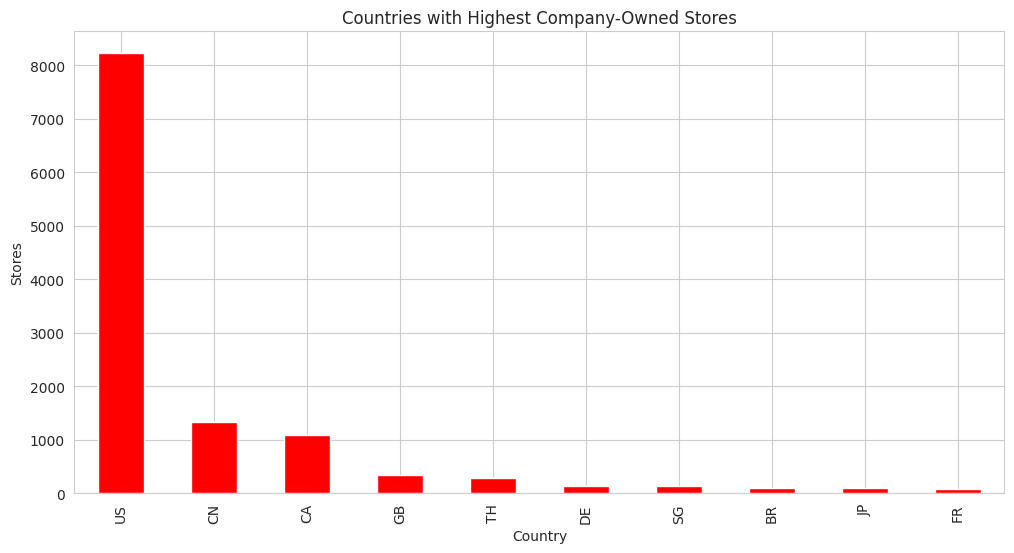

In [41]:
plt.figure(figsize=(12,6))
company_country.head(10).plot(kind='bar', color='red')
plt.title("Countries with Highest Company-Owned Stores")
plt.xlabel("Country")
plt.ylabel("Stores")
plt.show()

In [47]:
print("Total Starbucks Stores:", len(df))

Total Starbucks Stores: 25600


In [46]:
print("Countries:", df['Country'].nunique())

Countries: 73


In [45]:
print("Cities:", df['City'].nunique())

Cities: 5470


In [44]:
print(df['Ownership Type'].value_counts())

Ownership Type
Company Owned    11932
Licensed          9375
Joint Venture     3976
Franchise          317
Name: count, dtype: int64


In [43]:
country_percentage = (df['Country'].value_counts(normalize=True)*100).round(2)

print(country_percentage.head(10))

Country
US    53.16
CN    10.68
CA     5.73
JP     4.83
KR     3.88
GB     3.52
MX     2.26
TW     1.54
TR     1.27
PH     1.16
Name: proportion, dtype: float64


In [42]:
print("""
Conclusion

1. The United States has the highest number of Starbucks stores.
2. Some major cities contain significantly more stores than others.
3. Company-Owned stores represent the largest ownership type.
4. Starbucks has stores across many countries and time zones.
5. The dataset shows Starbucks has a strong global presence with thousands of stores worldwide.
""")


Conclusion

1. The United States has the highest number of Starbucks stores.
2. Some major cities contain significantly more stores than others.
3. Company-Owned stores represent the largest ownership type.
4. Starbucks has stores across many countries and time zones.
5. The dataset shows Starbucks has a strong global presence with thousands of stores worldwide.

